In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [17]:
from ml.preprocess import (
    load_detect_dataset,
    load_class_dataset,
    scale_data,
    create_sequences,
    get_dataset_stats,
    SENSOR_COLS,
)
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
from ml.isolation_forest import train_isolation_forest, get_anomaly_scores, save_model as save_if
from ml.lstm_model import train_lstm, get_reconstruction_errors, set_threshold, load_model
from ml.hybrid import hybrid_predict, classify_severity
from ml.explainability import (
    explain_with_shap,
    plot_shap_summary,
    explain_single_anomaly,
    get_top_contributing_sensors,
)
import numpy as np

In [18]:
# Preprocessing detect_dataset

X, y = load_detect_dataset("../data/raw/detect_dataset.csv")
get_dataset_stats(X, y)

feature_names = SENSOR_COLS   # ["Ia", "Ib", "Ic", "Va", "Vb", "Vc"]
X_scaled, scaler = scale_data(X)
X_seq, y_seq = create_sequences(X_scaled, y, timesteps=10)


   detect_dataset loaded: 12001 rows
   Normal: 6505 | Fault: 5496
   Fault rate: 45.8%

 Dataset Statistics:
              Ia         Ib         Ic         Va         Vb         Vc
count  12001.000  12001.000  12001.000  12001.000  12001.000  12001.000
mean       6.709    -26.558     22.353      0.011     -0.015      0.005
std      377.158    357.459    302.053      0.346      0.358      0.349
min     -883.542   -900.527   -883.358     -0.621     -0.660     -0.613
25%      -64.349    -51.422    -54.562     -0.238     -0.314     -0.279
50%       -3.240      4.711     -0.399      0.002     -0.007      0.008
75%       53.823     69.638     45.275      0.285      0.249      0.290
max      885.739    889.869    901.274      0.610      0.628      0.608

Class balance — Normal: 6505 | Fault: 5496


In [19]:
TIMESTEPS = 10
X_seq, y_seq = create_sequences(X_scaled, y, timesteps=TIMESTEPS)


In [20]:
if_model = train_isolation_forest(X_scaled)
if_scores, if_labels = get_anomaly_scores(if_model, X_scaled)
save_if(if_model, path="../models/isolation_forest.pkl")

  Isolation Forest saved → ../models/isolation_forest.pkl


In [21]:
normal_mask = y_seq == 0
X_normal_seq = X_seq[normal_mask]
lstm_model, train_losses = train_lstm(X_normal_seq, epochs=40)

Training on: cpu
Epoch   0 | Train Loss: 0.22801 | Val Loss: 0.16066
Epoch   5 | Train Loss: 0.01430 | Val Loss: 0.00782
Epoch  10 | Train Loss: 0.01062 | Val Loss: 0.00810
Epoch  15 | Train Loss: 0.00997 | Val Loss: 0.00747
Epoch  20 | Train Loss: 0.00897 | Val Loss: 0.00670
Epoch  25 | Train Loss: 0.00802 | Val Loss: 0.00593
Epoch  30 | Train Loss: 0.00774 | Val Loss: 0.00553
Epoch  35 | Train Loss: 0.00755 | Val Loss: 0.00520


In [22]:
# Save the new threshold
best_threshold = np.percentile(normal_errors, 95)  # adjust based on output above
with open("../models/threshold.txt", "w") as f:
    f.write(str(best_threshold))
print(f"✅ New threshold saved: {best_threshold:.5f}")

✅ New threshold saved: 0.00792


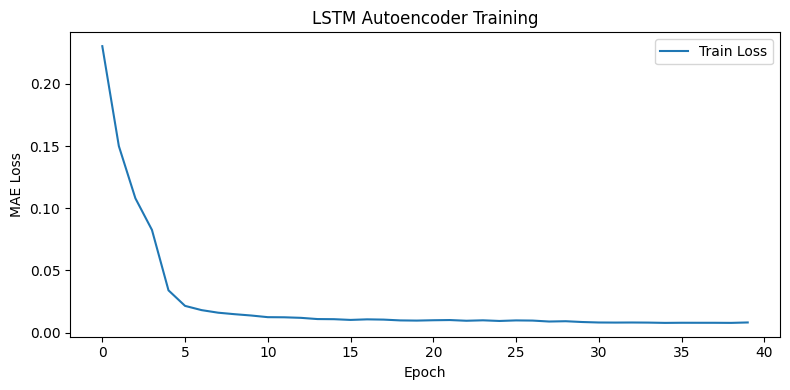

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch"); plt.ylabel("MAE Loss")
plt.title("LSTM Autoencoder Training")
plt.legend(); plt.tight_layout()
plt.savefig("../models/training_curve.png", dpi=150)


In [23]:
lstm_errors = get_reconstruction_errors(lstm_model, X_seq)
threshold = set_threshold(lstm_errors[normal_mask], percentile = 95)

 Anomaly threshold set at: 0.00897


In [9]:
#CHECK
normal_errors = lstm_errors[y_seq == 0]
fault_errors  = lstm_errors[y_seq == 1]

print(f"Normal  — Mean: {normal_errors.mean():.5f} | Std: {normal_errors.std():.5f}")
print(f"Fault   — Mean: {fault_errors.mean():.5f}  | Std: {fault_errors.std():.5f}")
print(f"Separation ratio: {fault_errors.mean() / normal_errors.mean():.2f}x")

Normal  — Mean: 0.00512 | Std: 0.00346
Fault   — Mean: 0.20743  | Std: 0.09832
Separation ratio: 40.51x


In [10]:
if_labels_seq = if_labels[TIMESTEPS:]
combined_labels, confidence_scores = hybrid_predict(if_labels_seq, lstm_errors, threshold)


In [11]:
print("\n Classification Report:")
print(classification_report(y_seq, combined_labels, target_names=["Normal", "Fault"]))

try:
    auc = roc_auc_score(y_seq, confidence_scores)
    print(f" ROC-AUC Score: {auc:.4f}")
except Exception as e:
    print(f"AUC error: {e}")



 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.86      0.93      6495
       Fault       0.86      1.00      0.93      5496

    accuracy                           0.93     11991
   macro avg       0.93      0.93      0.93     11991
weighted avg       0.94      0.93      0.93     11991

 ROC-AUC Score: 0.9942


In [12]:
print("\n Running SHAP explanations...")
shap_values = explain_with_shap(if_model, X_scaled, feature_names)
plot_shap_summary(shap_values, X_scaled, feature_names)

# Explain the first detected anomaly
anomaly_indices = np.where(combined_labels == 1)[0]
if len(anomaly_indices) > 0:
    sample = anomaly_indices[0]
    explain_single_anomaly(shap_values, X_scaled, sample, feature_names)
    reasons = get_top_contributing_sensors(shap_values, sample, feature_names)

    print(f"\n Anomaly #{sample} — Severity: {classify_severity(confidence_scores[sample])}")
    print("Root cause sensors:")
    for r in reasons:
        print(f"  → {r['sensor']}: {r['direction']} (impact: {r['impact']})")



 Running SHAP explanations...
 SHAP summary saved → ../models/shap_summary.png
 Explanation saved → ../models/explanation_0.png

 Anomaly #0 — Severity:  CRITICAL
Root cause sensors:
  → Vc: ↓ below normal (impact: -0.7986)
  → Vb: ↓ below normal (impact: -0.7978)
  → Ib: ↑ above normal (impact: 0.3483)


In [13]:
X_cls, y_cls_binary, y_cls_type = load_class_dataset("../data/raw/classData.csv")
X_cls_scaled, _ = scale_data(X_cls, scaler=scaler)  # reuse same scaler!

print("\n Fault type distribution:")
print(y_cls_type.value_counts())

   classData ed: 7861 rows
   Fault types found:
No Fault                2365
Phase AB + Ground       1134
Three Phase + Ground    1133
Phase A + Ground        1129
Phase ABC Fault         1096
Phase BC Fault          1004

 Fault type distribution:
No Fault                2365
Phase AB + Ground       1134
Three Phase + Ground    1133
Phase A + Ground        1129
Phase ABC Fault         1096
Phase BC Fault          1004
Name: count, dtype: int64


In [24]:
import joblib
joblib.dump(scaler, "../models/scaler.pkl")
print(" Scaler saved → ../models/scaler.pkl")

 Scaler saved → ../models/scaler.pkl
